In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
data = pd.read_csv("../Data/CustomersCleaned.csv")

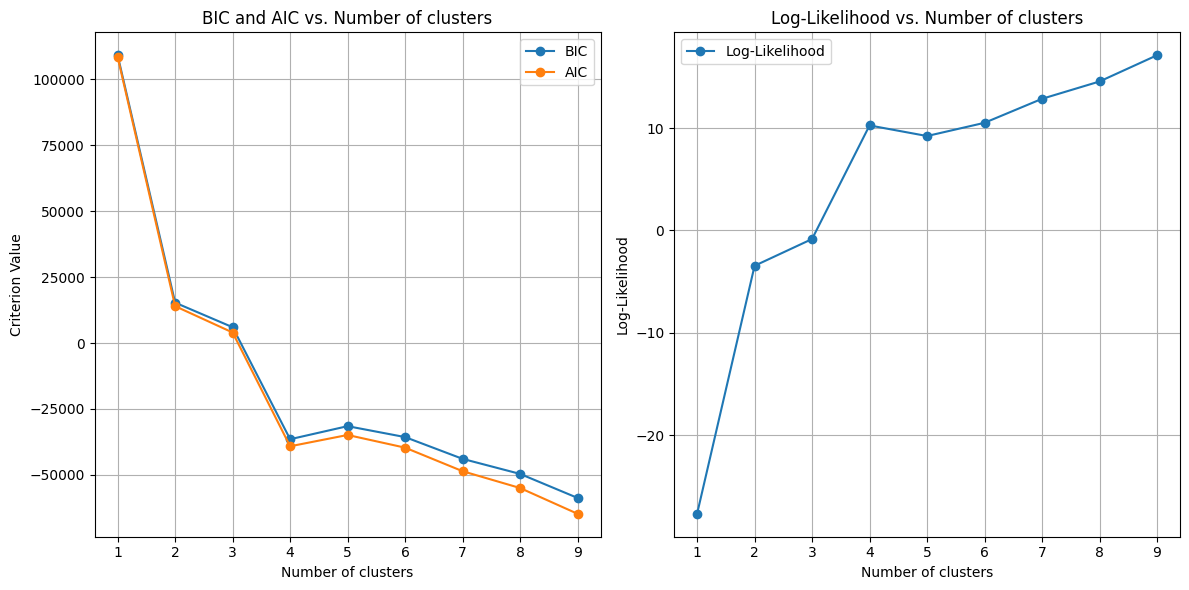

In [3]:
n_clusters = range(1, 10) 
log_likelihoods = []
bics = []
aics = []

for n in n_clusters:
    gmm = GaussianMixture(n_components=n, random_state=0)
    gmm.fit(data)
    log_likelihoods.append(gmm.score(data))  # Average log-likelihood
    bics.append(gmm.bic(data))
    aics.append(gmm.aic(data))
    
plt.figure(figsize=(12, 6))

# Log-Likelihood
plt.subplot(1, 2, 2)
plt.plot(n_clusters, log_likelihoods, marker="o", label="Log-Likelihood")
plt.title("Log-Likelihood vs. Number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Log-Likelihood")
plt.grid()
plt.legend()

# BIC and AIC
plt.subplot(1, 2, 1)
plt.plot(n_clusters, bics, marker="o", label="BIC")
plt.plot(n_clusters, aics, marker="o", label="AIC")
plt.title("BIC and AIC vs. Number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Criterion Value")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
G = GaussianMixture(n_components=4, random_state=0)
data["Cluster"] = G.fit_predict(data)

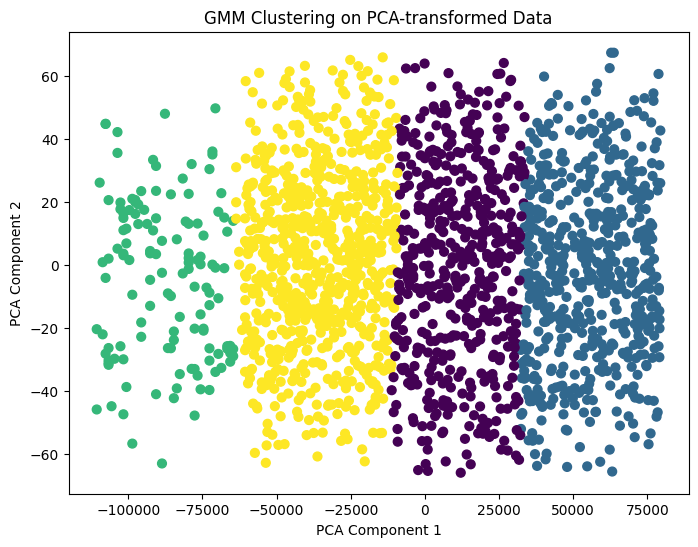

In [5]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

gmm_pca = GaussianMixture(n_components=4, random_state=0)
PCAA = gmm_pca.fit_predict(data_pca)

plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=PCAA, cmap="viridis", s=40)
plt.title("GMM Clustering on PCA-transformed Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [6]:
data.groupby("Cluster")[["Age", "Annual Income", "Spending Score (1-100)"]].agg(["mean", "min", "max"]).round(2)

Age         Annual Income               Spending Score (1-100)      \
          mean min max          mean   min     max                   mean min   
Cluster                                                                         
0        50.85   0  99     109970.90  5000  189974                  48.46   0   
1        47.53   0  99     112623.81  3000  189689                  50.12   1   
2        48.61   0  99     109255.00     0  189709                  52.56   1   
3        51.16   0  99     110650.33  1000  186882                  52.94   1   

              
         max  
Cluster       
0        100  
1        100  
2        100  
3        100

# Evaluation

In [8]:
X = data.drop("Cluster", axis=1)
labels = data["Cluster"]

dbi_gmm = davies_bouldin_score(X, labels)
sil_score = silhouette_score(X, labels)  # Silhouette Score

# Display the metrics
print(f"Silhouette Score: {sil_score:.2f}")
print(f"Davies-Bouldin Index: {dbi_gmm:.2f}")

Silhouette Score: -0.02
Davies-Bouldin Index: 93.66


### Model Comparison: GMM vs K-means

- **Davies-Bouldin Index**:
  - **GMM**: 93.66 --> higher values indicating poor cluster separation
  - **K-means**: 0.56 --> lower values, well-separated and well-defined clusters

- **Silhouette Score**:
  - **GMM**: -0.02 --> negative value, indicating bad clustering.
  - **K-means**: 0.56 --> value > 0.5 consider very good clustering

Based on the metrics, **K-means** is the better model. It has a significantly lower Davies-Bouldin Index and a higher Silhouette Score, indicating well-separated clusters.